# Member 6 - Feature Scaling

**Student ID:** IT25102309
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
Standardization using StandardScaler.

## Explanation
Feature scaling transforms numerical features so that differences in their
original measurement scales do not unnecessarily influence scale-sensitive
machine learning algorithms.

StandardScaler transforms a feature using its mean and standard deviation.

After standardization, training features should have approximately:

Mean = 0

Standard Deviation = 1

## Justification
The insurance dataset contains numerical predictor variables such as age, BMI,
and number of children, which have different numerical ranges.

Standardization places these continuous numerical variables on comparable
scales.

The dataset must be split into training and testing sets before fitting the
scaler. The scaler will be fitted only on the training data to prevent data
leakage.

## EDA
Histograms of the age feature before and after standardization will be compared.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Original Dataset Shape:", df.shape)

display(df.head())

Original Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

display(df_encoded.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [4]:
X = df_encoded.drop(
    "charges",
    axis=1
)

y = df_encoded["charges"]

print("Feature Dataset:", X.shape)
print("Target:", y.shape)

Feature Dataset: (1338, 8)
Target: (1338,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1070, 8)
Testing Shape: (268, 8)


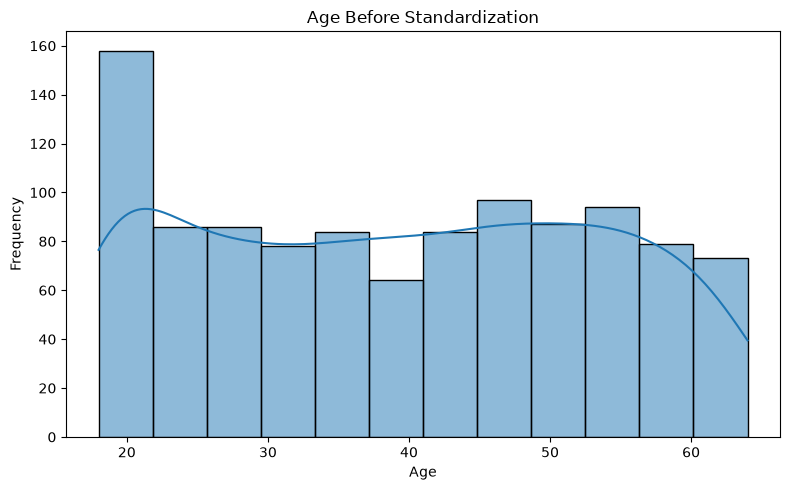

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    X_train["age"],
    kde=True
)

plt.title("Age Before Standardization")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member6_age_before_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
scale_columns = [
    "age",
    "bmi",
    "children"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

print("Standardization completed successfully.")

Standardization completed successfully.


In [8]:
print("Training Mean After Scaling:")

print(
    X_train_scaled[scale_columns]
    .mean()
    .round(3)
)

print("\nTraining Standard Deviation After Scaling:")

print(
    X_train_scaled[scale_columns]
    .std(ddof=0)
    .round(3)
)

Training Mean After Scaling:
age        -0.0
bmi        -0.0
children   -0.0
dtype: float64

Training Standard Deviation After Scaling:
age         1.0
bmi         1.0
children    1.0
dtype: float64


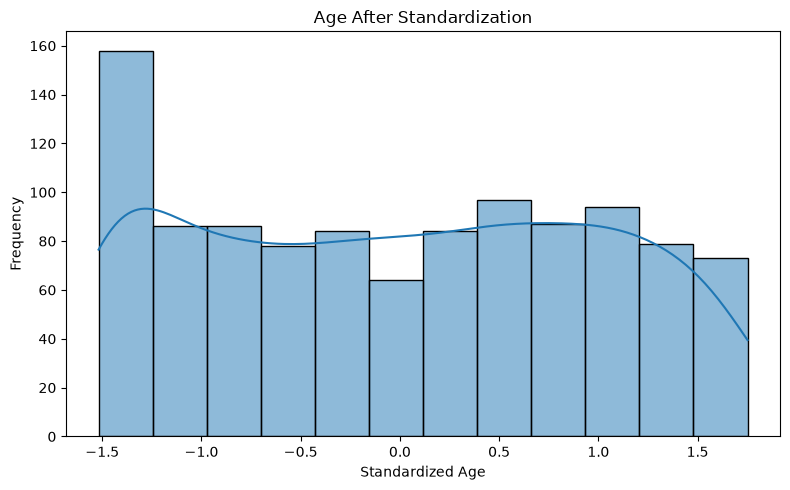

EDA visualizations saved successfully.


In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    X_train_scaled["age"],
    kde=True
)

plt.title("Age After Standardization")
plt.xlabel("Standardized Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member6_age_after_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("EDA visualizations saved successfully.")

## EDA Interpretation

Before standardization, age is represented using its original measurement
scale.

After StandardScaler is applied, the training values are centered around
approximately zero with a standard deviation of approximately one.

The overall distribution pattern remains similar because standardization
changes the scale of the feature rather than removing observations.

The scaler was fitted only on the training data and the learned transformation
was then applied to the testing data. This prevents test-set information from
leaking into the training preprocessing process.

In [10]:
train_output = X_train_scaled.copy()
train_output["charges"] = y_train

test_output = X_test_scaled.copy()
test_output["charges"] = y_test

member6_output = pd.concat(
    [train_output, test_output],
    axis=0
).sort_index()

member6_output.to_csv(
    "../results/outputs/member6_scaled.csv",
    index=False
)

print("Member 6 preprocessing completed.")

Member 6 preprocessing completed.
